In [16]:
import pandas as pd
import numpy as np
data=pd.read_csv('kmeans_knn_meanshift_data.csv')
data.head()

,V1,V2,labels
0,2.072345,-3.241693,0
1,17.936710,15.784810,0
2,1.083576,7.319176,0
3,11.120670,14.406780,0
4,23.711550,2.557729,0


In [17]:
X=data.drop(['labels'],axis=1)
print(X)
y=data.loc[:,'labels']
y.head()


             V1         V2
0      2.072345  -3.241693
1     17.936710  15.784810
2      1.083576   7.319176
3     11.120670  14.406780
4     23.711550   2.557729
...         ...        ...
2995  85.652800  -6.461061
2996  82.770880  -2.373299
2997  64.465320 -10.501360
2998  90.722820 -12.255840
2999  64.879760 -24.877310

[3000 rows x 2 columns]


0    0
1    0
2    0
3    0
4    0
Name: labels, dtype: int64

In [18]:
y.value_counts()

labels
2    1156
1     954
0     890
Name: count, dtype: int64

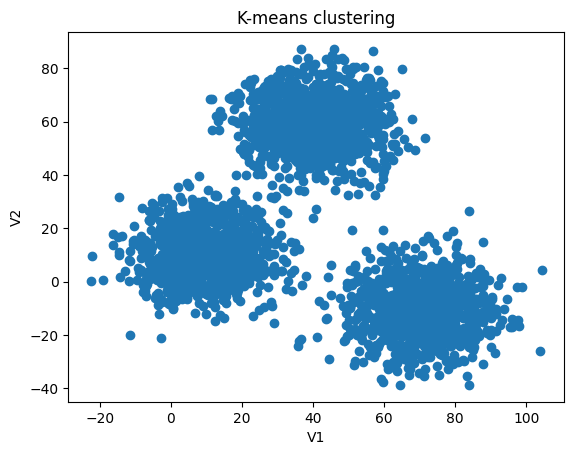

In [19]:
from matplotlib import pyplot as plt
fig1=plt.figure()
plt.scatter(X.loc[:,'V1'],X.loc[:,'V2'])
plt.title('K-means clustering')
plt.xlabel('V1')
plt.ylabel('V2')
plt.show()

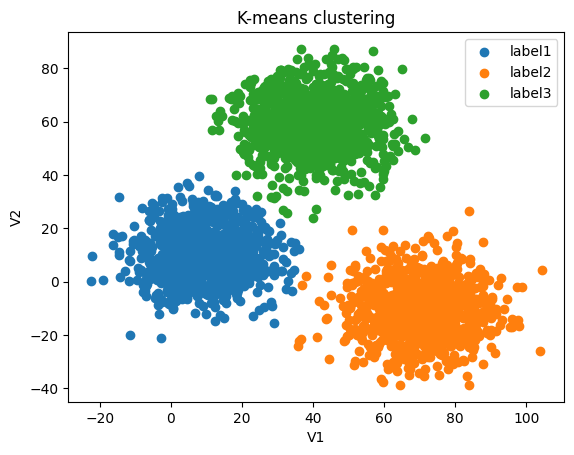

In [20]:
fig2=plt.figure()
label0=plt.scatter(X.loc[:,'V1'][y==0],X.loc[:,'V2'][y==0])
label1=plt.scatter(X.loc[:,'V1'][y==1],X.loc[:,'V2'][y==1])
label2=plt.scatter(X.loc[:,'V1'][y==2],X.loc[:,'V2'][y==2])
plt.title('K-means clustering')
plt.xlabel('V1')
plt.ylabel('V2')
plt.legend([label0,label1,label2],['label1','label2','label3'])
plt.show()

In [21]:
from sklearn.cluster import KMeans
KM=KMeans(n_clusters=3,random_state=0)
KM.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


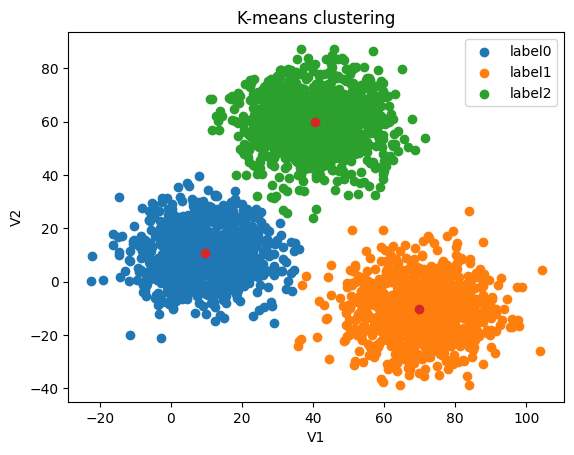

In [38]:
centers=KM.cluster_centers_
fig3=plt.figure()
label0=plt.scatter(X.loc[:,'V1'][y==0],X.loc[:,'V2'][y==0])
label1=plt.scatter(X.loc[:,'V1'][y==1],X.loc[:,'V2'][y==1])
label2=plt.scatter(X.loc[:,'V1'][y==2],X.loc[:,'V2'][y==2])
plt.title('K-means clustering')
plt.xlabel('V1')
plt.ylabel('V2')
plt.legend([label0,label1,label2],['label0','label1','label2'])

plt.scatter(centers[:,0],centers[:,1])

plt.show()

In [39]:

predict=KM.predict([[80,60]])
print(predict)

[0]


C:\Users\25776\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [40]:
import pandas as pd
y_predict=KM.predict(X)
pd.Series(y_predict).value_counts()

0    1149
1     952
2     899
Name: count, dtype: int64

In [42]:
from sklearn.metrics import accuracy_score
acc=accuracy_score(y,y_predict)
print(acc)


0.31966666666666665


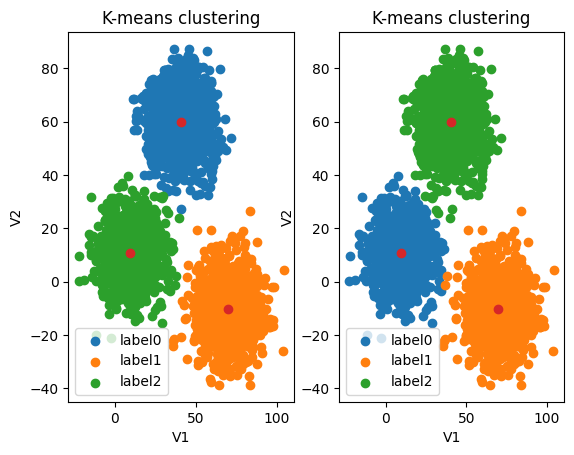

In [43]:
fig4=plt.subplot(121)
label0=plt.scatter(X.loc[:,'V1'][y_predict==0],X.loc[:,'V2'][y_predict==0])
label1=plt.scatter(X.loc[:,'V1'][y_predict==1],X.loc[:,'V2'][y_predict==1])
label2=plt.scatter(X.loc[:,'V1'][y_predict==2],X.loc[:,'V2'][y_predict==2])
plt.title('K-means clustering')
plt.xlabel('V1')
plt.ylabel('V2')
plt.legend([label0,label1,label2],['label0','label1','label2'])
plt.scatter(centers[:,0],centers[:,1])
fig4=plt.subplot(122)
label0=plt.scatter(X.loc[:,'V1'][y==0],X.loc[:,'V2'][y==0])
label1=plt.scatter(X.loc[:,'V1'][y==1],X.loc[:,'V2'][y==1])
label2=plt.scatter(X.loc[:,'V1'][y==2],X.loc[:,'V2'][y==2])
plt.title('K-means clustering')
plt.xlabel('V1')
plt.ylabel('V2')
plt.legend([label0,label1,label2],['label0','label1','label2'])
plt.scatter(centers[:,0],centers[:,1])
plt.show()

In [46]:
y_corrected=[]
for i in y_predict:
    if i==0:
        y_corrected.append(2)
    elif i==1:
        y_corrected.append(1)
    elif i==2:
        y_corrected.append(0)

pd.Series(y_corrected).value_counts()

2    1149
1     952
0     899
Name: count, dtype: int64

In [48]:
print(accuracy_score(y_corrected,y))

0.997


In [49]:
#knn
from sklearn.neighbors import KNeighborsClassifier
KNN=KNeighborsClassifier(n_neighbors=3)
KNN.fit(X,y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [53]:
predict_test=KNN.predict([[80,60]])
predict_KNN=KNN.predict(X)
print(predict_test)
print(accuracy_score(predict_KNN,y))

[2]
1.0


C:\Users\25776\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [55]:
print(pd.Series(predict_KNN).value_counts())

2    1156
1     954
0     890
Name: count, dtype: int64


In [56]:
#meanshift
from sklearn.cluster import MeanShift,estimate_bandwidth
bandwidth=estimate_bandwidth(X,n_samples=500)
print(bandwidth)


30.84663454820215


In [57]:
ms=MeanShift(bandwidth=bandwidth)
ms.fit(X)


[[ 40.60158864  59.65137971]
 [ 70.01854306 -10.11803404]
 [  9.56752568  10.79316266]]


In [59]:
y_ms_pre=ms.predict(X)
print(pd.Series(y_ms_pre).value_counts())
#矫正

0    1149
1     952
2     899
Name: count, dtype: int64


In [60]:
y_corrected=[]
for i in y_ms_pre:
    if i==0:
        y_corrected.append(2)
    elif i==1:
        y_corrected.append(1)
    elif i==2:
        y_corrected.append(0)

pd.Series(y_corrected).value_counts()

2    1149
1     952
0     899
Name: count, dtype: int64